# Matplotlib — Complete Reference Notebook

**What is Matplotlib?** Matplotlib is the foundational plotting library in Python. In ML, you use it to visualize data distributions, model performance, decision boundaries, feature importance, and more.

**What this notebook covers:** Every plot type you need in ML work, from basic line plots to subplots with custom styling.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/YOUR_USERNAME/ml-mastery/blob/main/01_libraries/matplotlib.ipynb)

---

## Table of Contents
1. [Import & Setup](#1-import--setup)
2. [Figure & Axes — the right mental model](#2-figure--axes)
3. [Line Plot](#3-line-plot)
4. [Scatter Plot](#4-scatter-plot)
5. [Bar Chart](#5-bar-chart)
6. [Histogram](#6-histogram)
7. [Box Plot](#7-box-plot)
8. [Heatmap](#8-heatmap)
9. [Subplots](#9-subplots)
10. [Styling & Formatting](#10-styling--formatting)
11. [Saving Figures](#11-saving-figures)
12. [ML-specific Plots](#12-ml-specific-plots)
13. [Common Gotchas](#13-common-gotchas)
14. [Exercises](#14-exercises)


## 1. Import & Setup

In [28]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import pandas as pd

print("Matplotlib version:", mpl.__version__)

# Recommended style — clean and readable
plt.style.use('seaborn-v0_8-whitegrid')


Matplotlib version: 3.10.0


## 2. Figure & Axes — the right mental model

**Always use the object-oriented API** (`fig, ax = plt.subplots()`). It is explicit, composable, and does not break when you have multiple plots.

```
Figure  →  the entire canvas (the window or image file)
  └─ Axes  →  one individual plot area inside the figure
       ├─ x-axis, y-axis
       ├─ title, labels
       └─ all the actual data (lines, bars, etc.)
```

`plt.plot()` is a shortcut that operates on the **current** figure/axes. Fine for quick exploration, but use `ax.plot()` for anything you will reuse or put in a notebook.


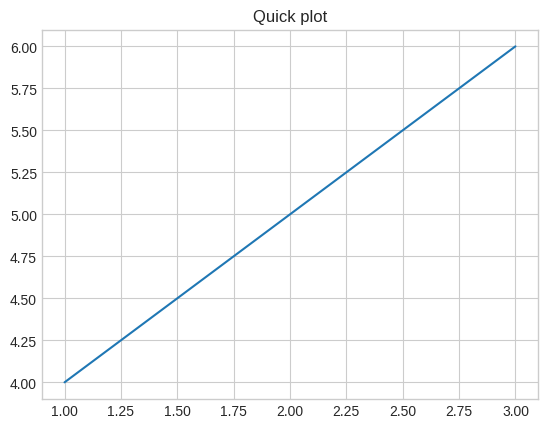

In [29]:
# Shortcut style (quick but less controllable)
plt.plot([1, 2, 3], [4, 5, 6])
plt.title("Quick plot")
plt.show()


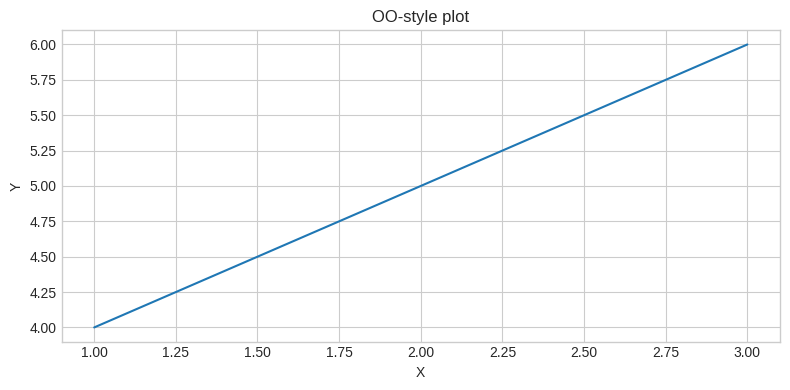

In [30]:
# Object-oriented style (always use this in practice)
fig, ax = plt.subplots(figsize=(8, 4))   # figsize in inches
ax.plot([1, 2, 3], [4, 5, 6])
ax.set_title("OO-style plot")
ax.set_xlabel("X")
ax.set_ylabel("Y")
plt.tight_layout()
plt.show()


## 3. Line Plot

Used for: training/validation loss curves, time series, continuous functions.

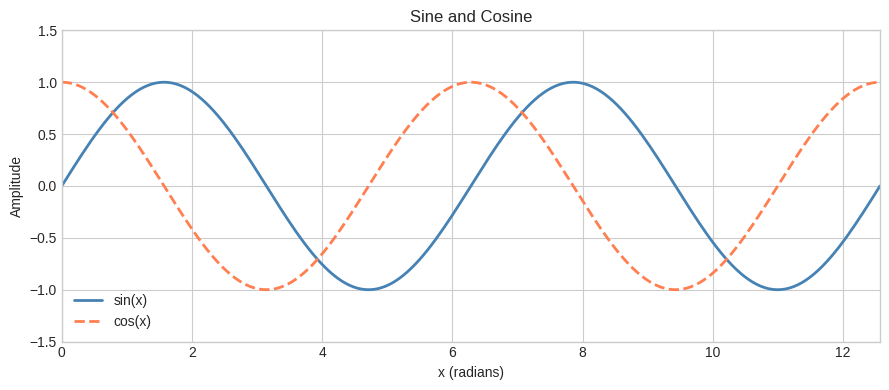

In [31]:
x = np.linspace(0, 4 * np.pi, 200)
y1 = np.sin(x)
y2 = np.cos(x)

fig, ax = plt.subplots(figsize=(9, 4))

ax.plot(x, y1, color='steelblue', linewidth=2,   linestyle='-',  label='sin(x)')
ax.plot(x, y2, color='coral',     linewidth=2,   linestyle='--', label='cos(x)')

ax.set_title("Sine and Cosine")
ax.set_xlabel("x (radians)")
ax.set_ylabel("Amplitude")
ax.legend()
ax.set_xlim(0, 4 * np.pi)
ax.set_ylim(-1.5, 1.5)

plt.tight_layout()
plt.show()


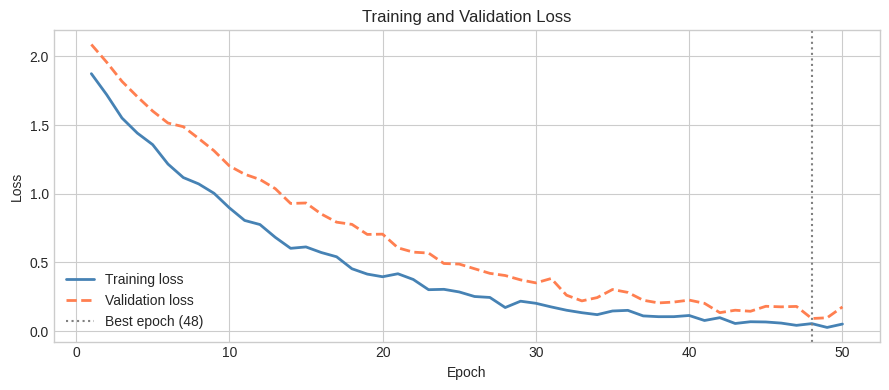

In [32]:
# Training/validation loss curve — the most common ML plot
epochs     = np.arange(1, 51)
train_loss = 2.0 * np.exp(-0.08 * epochs) + np.random.normal(0, 0.02, 50)
val_loss   = 2.2 * np.exp(-0.06 * epochs) + np.random.normal(0, 0.04, 50)

fig, ax = plt.subplots(figsize=(9, 4))

ax.plot(epochs, train_loss, color='steelblue', label='Training loss',   linewidth=2)
ax.plot(epochs, val_loss,   color='coral',     label='Validation loss', linewidth=2, linestyle='--')

# Mark the best epoch
best_epoch = np.argmin(val_loss) + 1
ax.axvline(x=best_epoch, color='gray', linestyle=':', linewidth=1.5, label=f'Best epoch ({best_epoch})')

ax.set_title("Training and Validation Loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.legend()
plt.tight_layout()
plt.show()


## 4. Scatter Plot

Used for: feature relationships, cluster visualization, actual vs predicted values.

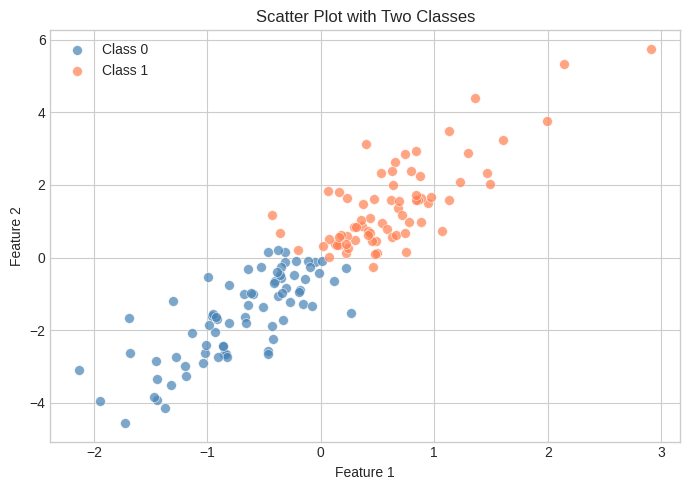

In [33]:
rng = np.random.default_rng(42)

n = 150
x = rng.normal(0, 1, n)
y = 2 * x + rng.normal(0, 0.8, n)
classes = (x + y > 0).astype(int)

fig, ax = plt.subplots(figsize=(7, 5))

colors = {0: 'steelblue', 1: 'coral'}
labels = {0: 'Class 0', 1: 'Class 1'}

for cls in [0, 1]:
    mask = classes == cls
    ax.scatter(x[mask], y[mask],
               c=colors[cls], label=labels[cls],
               s=50, alpha=0.7, edgecolors='white', linewidths=0.5)

ax.set_title("Scatter Plot with Two Classes")
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
ax.legend()
plt.tight_layout()
plt.show()


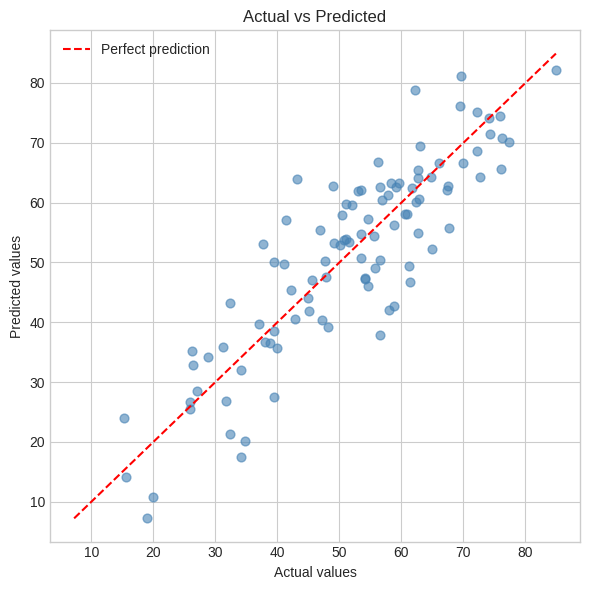

In [34]:
# Actual vs Predicted — standard regression diagnostic plot
y_actual    = rng.normal(50, 15, 100)
y_predicted = y_actual + rng.normal(0, 8, 100)

fig, ax = plt.subplots(figsize=(6, 6))

ax.scatter(y_actual, y_predicted, alpha=0.6, color='steelblue', s=40)

# Perfect prediction line
min_val = min(y_actual.min(), y_predicted.min())
max_val = max(y_actual.max(), y_predicted.max())
ax.plot([min_val, max_val], [min_val, max_val],
        color='red', linewidth=1.5, linestyle='--', label='Perfect prediction')

ax.set_title("Actual vs Predicted")
ax.set_xlabel("Actual values")
ax.set_ylabel("Predicted values")
ax.legend()
plt.tight_layout()
plt.show()


## 5. Bar Chart

Used for: feature importance, category counts, model comparison.

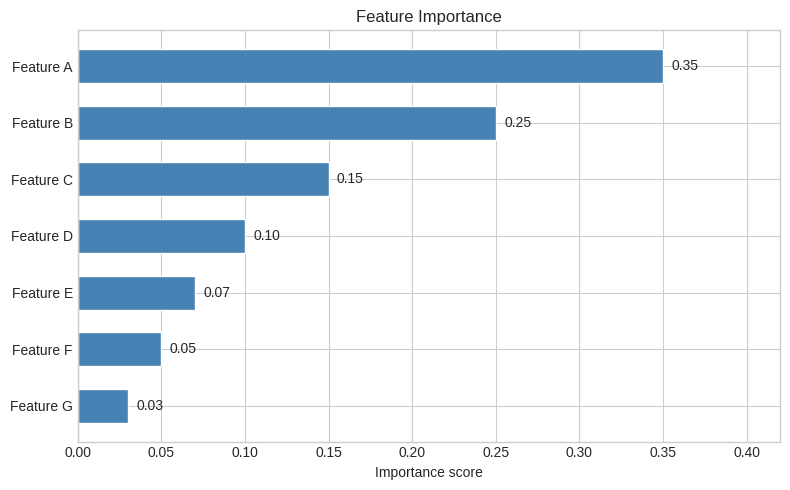

In [35]:
# Horizontal bar chart — best for feature importance (labels are readable)
features = ['Feature A', 'Feature B', 'Feature C', 'Feature D', 'Feature E',
            'Feature F', 'Feature G']
importances = np.array([0.35, 0.25, 0.15, 0.10, 0.07, 0.05, 0.03])

# Sort for readability
order = np.argsort(importances)
features_sorted = [features[i] for i in order]
importances_sorted = importances[order]

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.barh(features_sorted, importances_sorted,
               color='steelblue', edgecolor='white', height=0.6)

# Add value labels on bars
for bar, val in zip(bars, importances_sorted):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', fontsize=10)

ax.set_title("Feature Importance")
ax.set_xlabel("Importance score")
ax.set_xlim(0, 0.42)
plt.tight_layout()
plt.show()


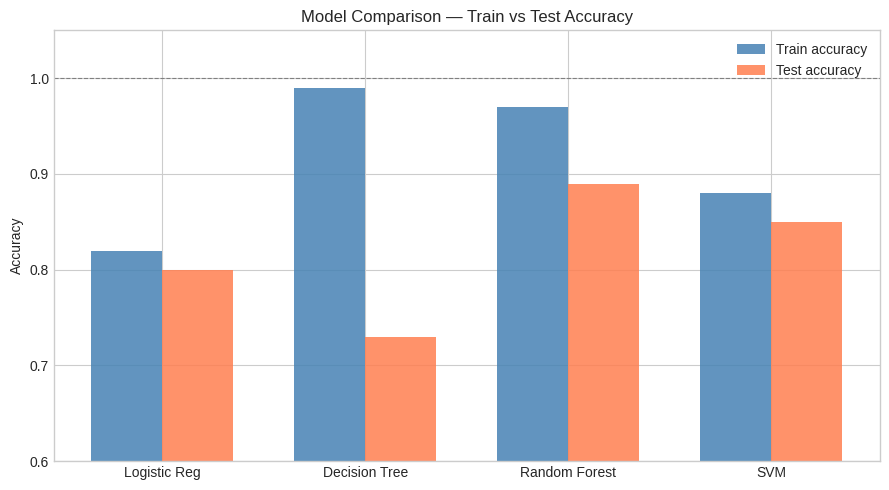

In [36]:
# Grouped bar chart — model comparison
models  = ['Logistic Reg', 'Decision Tree', 'Random Forest', 'SVM']
train_acc = [0.82, 0.99, 0.97, 0.88]
test_acc  = [0.80, 0.73, 0.89, 0.85]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
b1 = ax.bar(x - width/2, train_acc, width, label='Train accuracy', color='steelblue', alpha=0.85)
b2 = ax.bar(x + width/2, test_acc,  width, label='Test accuracy',  color='coral',     alpha=0.85)

ax.set_title("Model Comparison — Train vs Test Accuracy")
ax.set_ylabel("Accuracy")
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0.6, 1.05)
ax.legend()
ax.axhline(1.0, color='gray', linewidth=0.8, linestyle='--')
plt.tight_layout()
plt.show()


## 6. Histogram

Used for: understanding data distributions, checking skewness, comparing feature distributions before/after transformation.

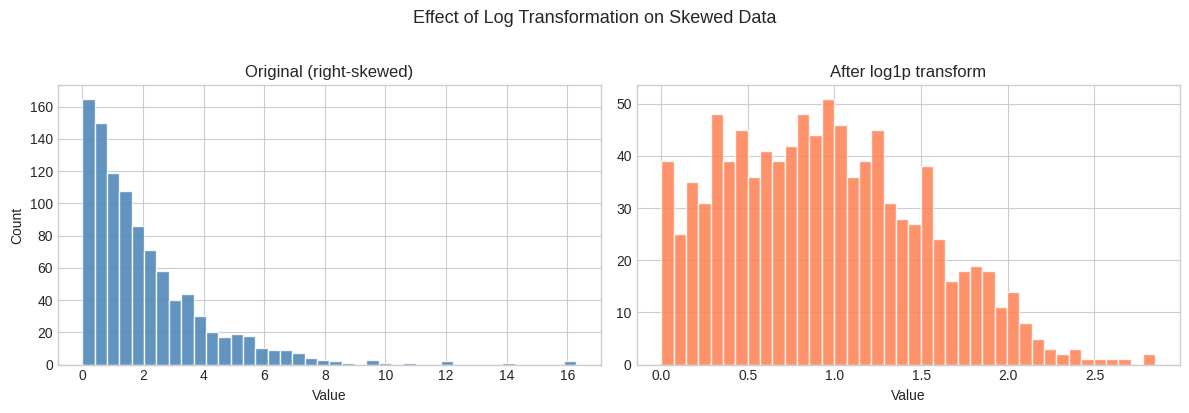

In [37]:
rng = np.random.default_rng(0)
data_skewed = rng.exponential(scale=2, size=1000)
data_normal = np.log1p(data_skewed)       # log transform to reduce skew

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(data_skewed, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title("Original (right-skewed)")
axes[0].set_xlabel("Value")
axes[0].set_ylabel("Count")

axes[1].hist(data_normal, bins=40, color='coral', edgecolor='white', alpha=0.85)
axes[1].set_title("After log1p transform")
axes[1].set_xlabel("Value")

plt.suptitle("Effect of Log Transformation on Skewed Data", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()


## 7. Box Plot

Used for: spotting outliers, comparing distributions across groups.

/tmp/ipykernel_817/3133045945.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(groups.values(),


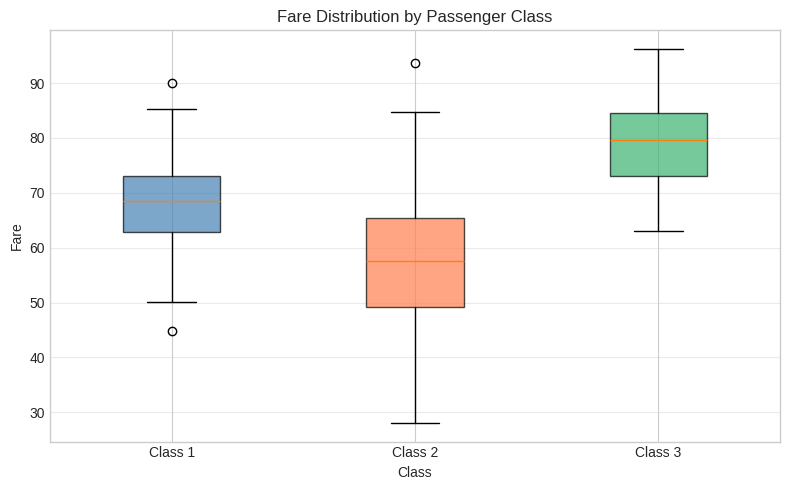

In [38]:
rng = np.random.default_rng(7)

groups = {
    'Class 1': rng.normal(70, 10, 80),
    'Class 2': rng.normal(60, 15, 80),
    'Class 3': rng.normal(80, 8,  80),
}

fig, ax = plt.subplots(figsize=(8, 5))

bp = ax.boxplot(groups.values(),
                labels=groups.keys(),
                patch_artist=True,
                notch=False,
                widths=0.4)

colors = ['steelblue', 'coral', 'mediumseagreen']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_title("Fare Distribution by Passenger Class")
ax.set_xlabel("Class")
ax.set_ylabel("Fare")
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

# Reading a box plot:
# Box = IQR (25th to 75th percentile)
# Line inside box = median
# Whiskers = 1.5 * IQR from box edges
# Points beyond whiskers = outliers


## 8. Heatmap

Used for: correlation matrices, confusion matrices.

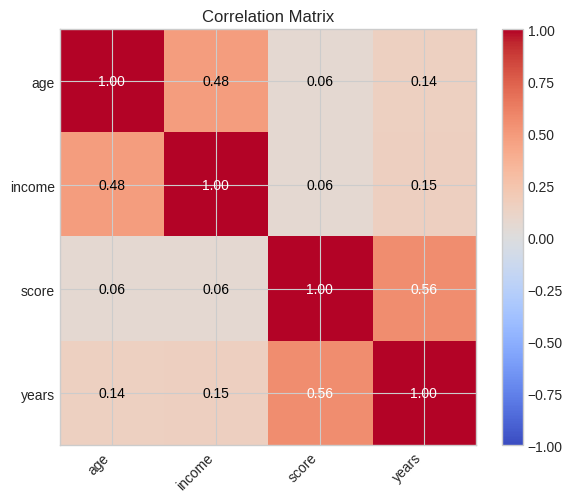

In [39]:
# Correlation matrix heatmap
rng = np.random.default_rng(1)
n = 100
df_corr = pd.DataFrame({
    'age':    rng.normal(35, 10, n),
    'income': rng.normal(50000, 15000, n),
    'score':  rng.normal(70, 15, n),
    'years':  rng.normal(5, 3, n),
})
df_corr['income'] = df_corr['income'] + df_corr['age'] * 1000   # add correlation
df_corr['score']  = df_corr['score']  + df_corr['years'] * 3

corr = df_corr.corr()

fig, ax = plt.subplots(figsize=(6, 5))

im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)

cols = corr.columns.tolist()
ax.set_xticks(range(len(cols)))
ax.set_yticks(range(len(cols)))
ax.set_xticklabels(cols, rotation=45, ha='right')
ax.set_yticklabels(cols)

for i in range(len(cols)):
    for j in range(len(cols)):
        ax.text(j, i, f'{corr.iloc[i,j]:.2f}',
                ha='center', va='center', fontsize=10,
                color='white' if abs(corr.iloc[i,j]) > 0.5 else 'black')

ax.set_title("Correlation Matrix")
plt.tight_layout()
plt.show()


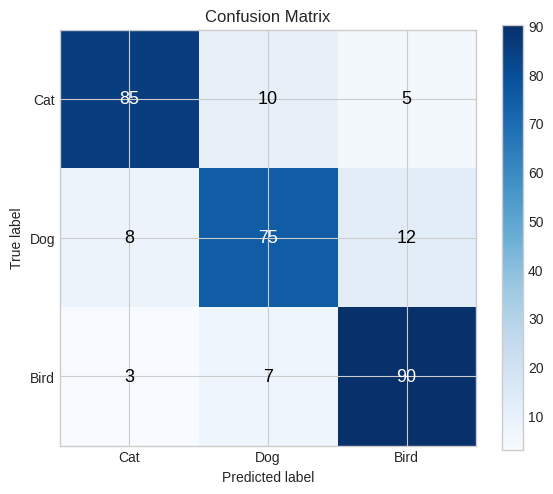

In [40]:
# Confusion matrix heatmap
conf_matrix = np.array([[85, 10,  5],
                         [ 8, 75, 12],
                         [ 3,  7, 90]])
class_names = ['Cat', 'Dog', 'Bird']

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(conf_matrix, cmap='Blues')
plt.colorbar(im, ax=ax)

ax.set_xticks(range(3))
ax.set_yticks(range(3))
ax.set_xticklabels(class_names)
ax.set_yticklabels(class_names)
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title("Confusion Matrix")

for i in range(3):
    for j in range(3):
        ax.text(j, i, str(conf_matrix[i, j]),
                ha='center', va='center', fontsize=13,
                color='white' if conf_matrix[i,j] > 60 else 'black')

plt.tight_layout()
plt.show()


## 9. Subplots

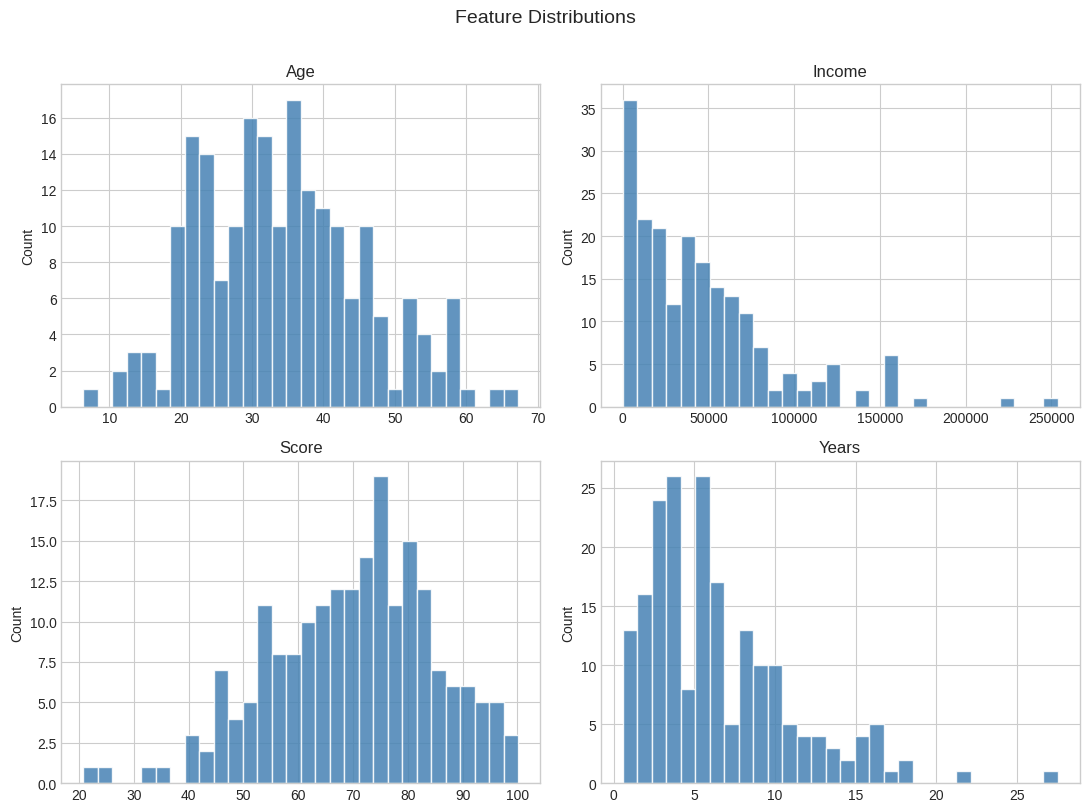

In [41]:
# Grid of subplots — most common pattern
rng = np.random.default_rng(5)
features = {
    'Age':    rng.normal(35, 12, 200),
    'Income': rng.exponential(50000, 200),
    'Score':  rng.normal(70, 15, 200),
    'Years':  rng.gamma(2, 3, 200),
}

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
axes = axes.flatten()   # easier to iterate

for idx, (name, data) in enumerate(features.items()):
    axes[idx].hist(data, bins=30, color='steelblue', edgecolor='white', alpha=0.85)
    axes[idx].set_title(name)
    axes[idx].set_ylabel("Count")

plt.suptitle("Feature Distributions", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


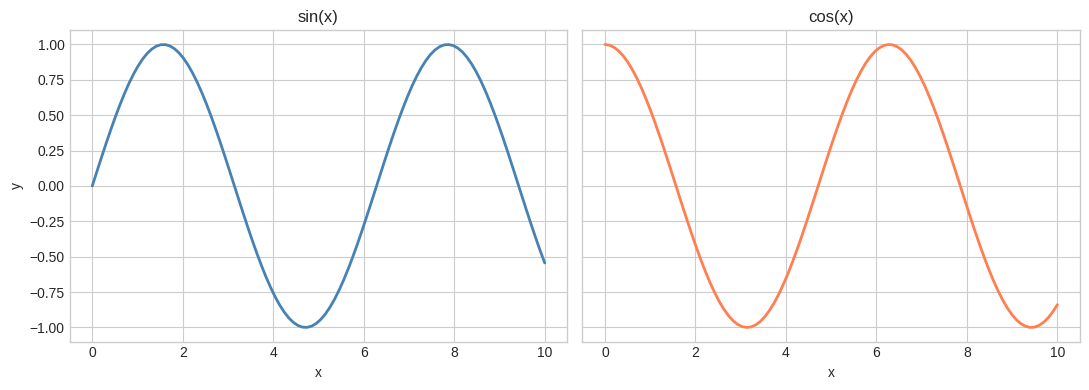

In [42]:
# Shared axes — useful when comparing plots at the same scale
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)

x = np.linspace(0, 10, 100)
axes[0].plot(x, np.sin(x), color='steelblue', linewidth=2)
axes[0].set_title("sin(x)")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")

axes[1].plot(x, np.cos(x), color='coral', linewidth=2)
axes[1].set_title("cos(x)")
axes[1].set_xlabel("x")
# No ylabel needed — shared with left plot

plt.tight_layout()
plt.show()


## 10. Styling & Formatting

In [43]:
# Available styles
print("Available styles:")
for s in plt.style.available:
    print(" ", s)


Available styles:
  Solarize_Light2
  _classic_test_patch
  _mpl-gallery
  _mpl-gallery-nogrid
  bmh
  classic
  dark_background
  fast
  fivethirtyeight
  ggplot
  grayscale
  petroff10
  seaborn-v0_8
  seaborn-v0_8-bright
  seaborn-v0_8-colorblind
  seaborn-v0_8-dark
  seaborn-v0_8-dark-palette
  seaborn-v0_8-darkgrid
  seaborn-v0_8-deep
  seaborn-v0_8-muted
  seaborn-v0_8-notebook
  seaborn-v0_8-paper
  seaborn-v0_8-pastel
  seaborn-v0_8-poster
  seaborn-v0_8-talk
  seaborn-v0_8-ticks
  seaborn-v0_8-white
  seaborn-v0_8-whitegrid
  tableau-colorblind10


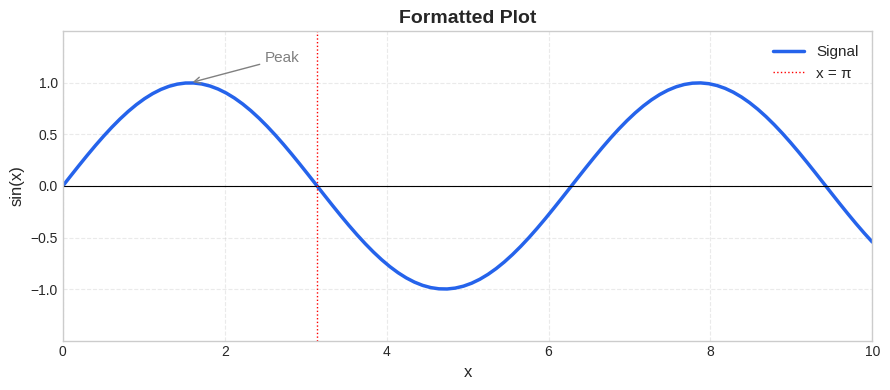

In [44]:
# Commonly used formatting options
fig, ax = plt.subplots(figsize=(9, 4))

x = np.linspace(0, 10, 100)
ax.plot(x, np.sin(x), color='#2563EB', linewidth=2.5, label='Signal')

# Axis limits
ax.set_xlim(0, 10)
ax.set_ylim(-1.5, 1.5)

# Ticks
ax.set_xticks(np.arange(0, 11, 2))
ax.set_yticks([-1, -0.5, 0, 0.5, 1])

# Grid
ax.grid(True, which='both', linestyle='--', alpha=0.4)

# Text annotation
ax.annotate('Peak', xy=(np.pi/2, 1), xytext=(2.5, 1.2),
            arrowprops=dict(arrowstyle='->', color='gray'),
            fontsize=11, color='gray')

# Horizontal/vertical reference lines
ax.axhline(y=0, color='black', linewidth=0.8)
ax.axvline(x=np.pi, color='red', linewidth=1, linestyle=':', label='x = π')

ax.set_title("Formatted Plot", fontsize=14, fontweight='bold')
ax.set_xlabel("x", fontsize=12)
ax.set_ylabel("sin(x)", fontsize=12)
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()


## 11. Saving Figures

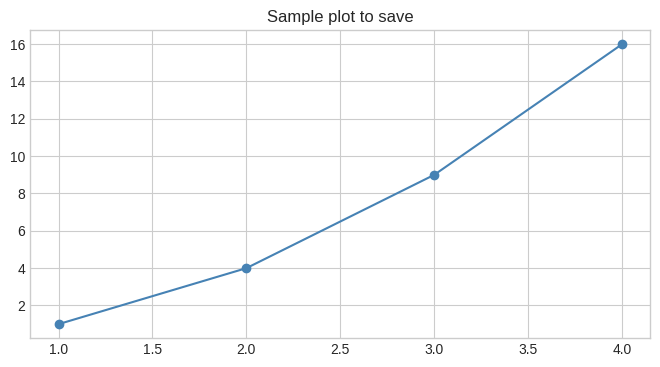

Figure saved as PNG, PDF, and SVG


In [45]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot([1, 2, 3, 4], [1, 4, 9, 16], 'o-', color='steelblue')
ax.set_title("Sample plot to save")

# Always call savefig BEFORE show — show() resets the figure state
fig.savefig('sample_plot.png', dpi=150, bbox_inches='tight')   # PNG for presentations
fig.savefig('sample_plot.pdf', bbox_inches='tight')            # PDF for papers/LaTeX
fig.savefig('sample_plot.svg', bbox_inches='tight')            # SVG for web

plt.show()
print("Figure saved as PNG, PDF, and SVG")


## 12. ML-specific Plots

These are the plots you will use most often when evaluating models.

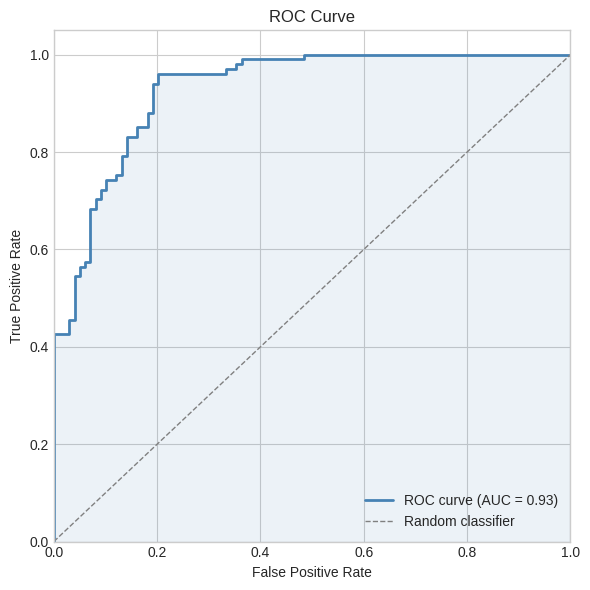

In [46]:
# ROC Curve
from sklearn.metrics import roc_curve, auc

rng = np.random.default_rng(42)
y_true  = rng.integers(0, 2, 200)
y_score = y_true * 0.6 + rng.normal(0, 0.3, 200)

fpr, tpr, thresholds = roc_curve(y_true, y_score)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(fpr, tpr, color='steelblue', linewidth=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
ax.plot([0, 1], [0, 1], color='gray', linewidth=1, linestyle='--', label='Random classifier')
ax.fill_between(fpr, tpr, alpha=0.1, color='steelblue')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()


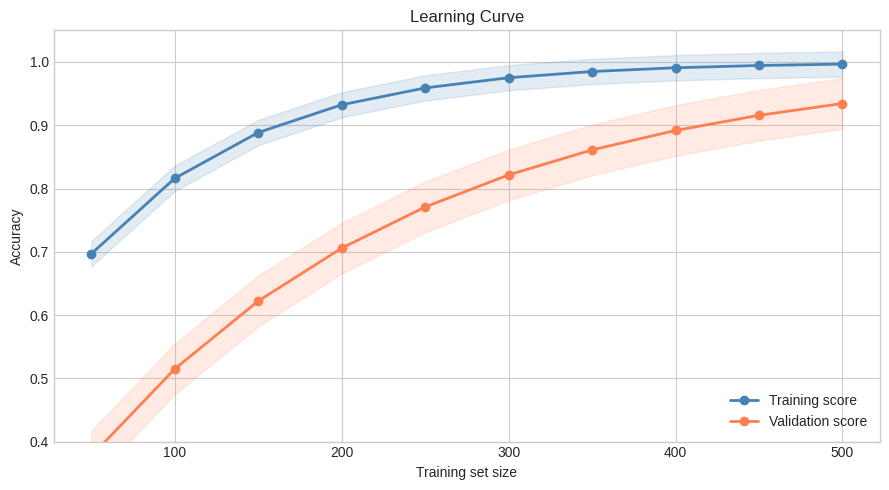

In [47]:
# Learning curve — diagnose overfitting/underfitting
train_sizes = np.arange(50, 501, 50)
train_scores_mean = 1 - 0.5 * np.exp(-train_sizes / 100)
train_scores_std  = 0.02 * np.ones(len(train_sizes))
val_scores_mean   = 1 - 0.8 * np.exp(-train_sizes / 200)
val_scores_std    = 0.04 * np.ones(len(train_sizes))

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(train_sizes, train_scores_mean, 'o-', color='steelblue', linewidth=2, label='Training score')
ax.fill_between(train_sizes,
                train_scores_mean - train_scores_std,
                train_scores_mean + train_scores_std,
                alpha=0.15, color='steelblue')

ax.plot(train_sizes, val_scores_mean, 'o-', color='coral', linewidth=2, label='Validation score')
ax.fill_between(train_sizes,
                val_scores_mean - val_scores_std,
                val_scores_mean + val_scores_std,
                alpha=0.15, color='coral')

ax.set_title("Learning Curve")
ax.set_xlabel("Training set size")
ax.set_ylabel("Accuracy")
ax.legend(loc='lower right')
ax.set_ylim(0.4, 1.05)
plt.tight_layout()
plt.show()


## 13. Common Gotchas

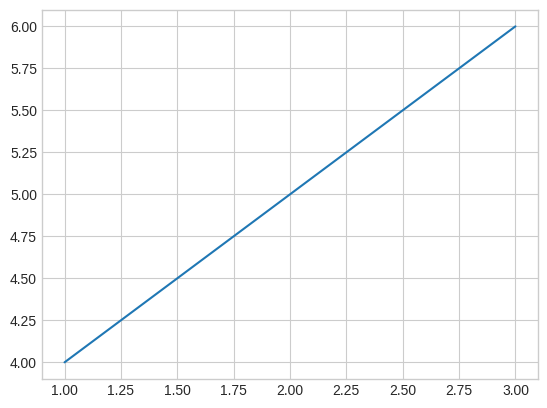

Correct: savefig before show


In [48]:
# GOTCHA 1: savefig AFTER show() saves a blank image
fig, ax = plt.subplots()
ax.plot([1, 2, 3], [4, 5, 6])

# WRONG order:
# plt.show()           # this clears the figure
# fig.savefig(...)     # saves a blank image

# CORRECT order:
fig.savefig('/tmp/test_plot.png', dpi=100, bbox_inches='tight')
plt.show()
print("Correct: savefig before show")


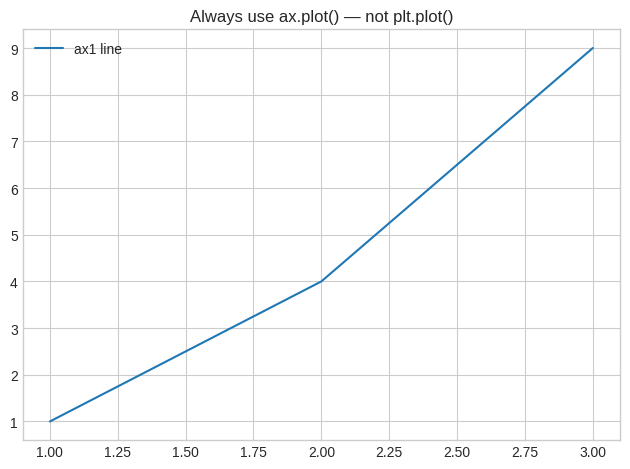

In [49]:
# GOTCHA 2: plt.plot() vs ax.plot() — state confusion
fig1, ax1 = plt.subplots()
ax1.plot([1, 2, 3], [1, 4, 9], label='ax1 line')

# plt.plot() adds to the CURRENT axes — could be ax1 or something else
# When you have multiple figures/axes, this becomes unpredictable
# Always use ax.plot() explicitly

ax1.set_title("Always use ax.plot() — not plt.plot()")
ax1.legend()
plt.tight_layout()
plt.show()


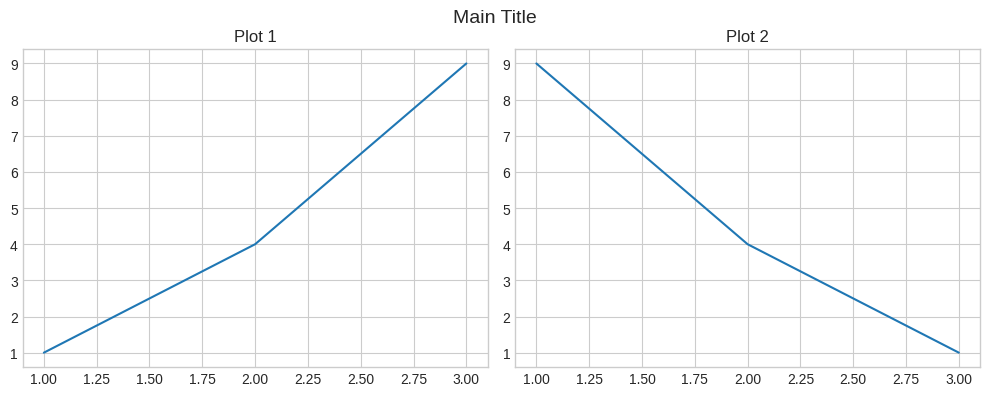

In [50]:
# GOTCHA 3: tight_layout conflicts with suptitle
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot([1,2,3], [1,4,9])
axes[0].set_title("Plot 1")
axes[1].plot([1,2,3], [9,4,1])
axes[1].set_title("Plot 2")

# suptitle gets cut off with just tight_layout
plt.suptitle("Main Title", fontsize=14)
plt.tight_layout()
plt.subplots_adjust(top=0.88)   # fix: manually adjust top margin

plt.show()


## 14. Exercises

**Exercise 1:** Create a 1x3 subplot figure showing: (a) a histogram of 500 samples from a normal distribution, (b) the same data as a cumulative histogram, and (c) a box plot of the same data. Use consistent colors and proper titles.

In [51]:
# Your code here


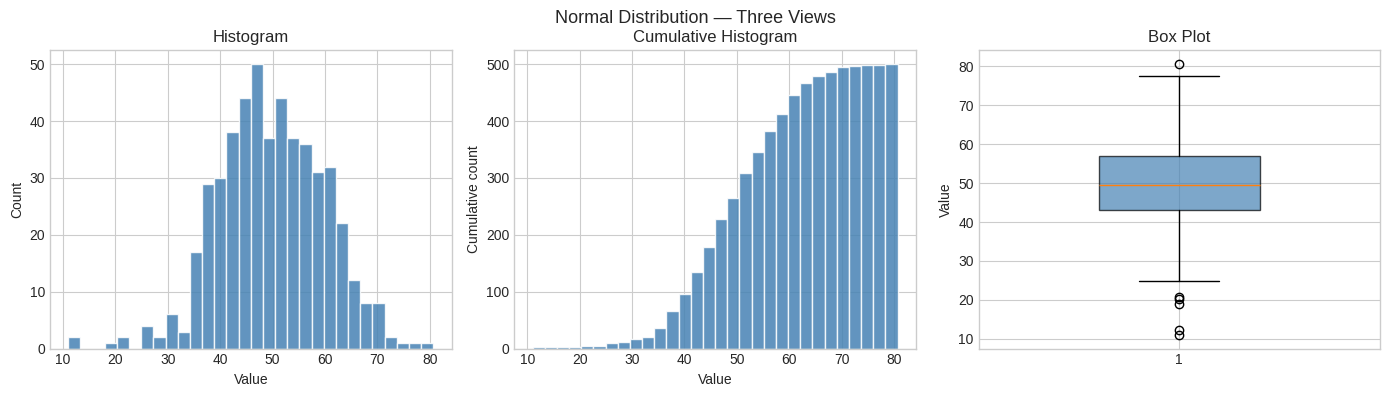

In [52]:
# Solution
rng = np.random.default_rng(0)
data = rng.normal(50, 10, 500)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].hist(data, bins=30, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title("Histogram")
axes[0].set_xlabel("Value")
axes[0].set_ylabel("Count")

axes[1].hist(data, bins=30, cumulative=True, color='steelblue', edgecolor='white', alpha=0.85)
axes[1].set_title("Cumulative Histogram")
axes[1].set_xlabel("Value")
axes[1].set_ylabel("Cumulative count")

bp = axes[2].boxplot(data, patch_artist=True, widths=0.4)
bp['boxes'][0].set_facecolor('steelblue')
bp['boxes'][0].set_alpha(0.7)
axes[2].set_title("Box Plot")
axes[2].set_ylabel("Value")

plt.suptitle("Normal Distribution — Three Views", fontsize=13)
plt.tight_layout()
plt.subplots_adjust(top=0.88)
plt.show()


**Exercise 2:** Plot the decision boundary of a simple threshold classifier. Given points in 2D space with two classes, draw the scatter plot and shade the two decision regions in different colors.

In [53]:
# Your code here


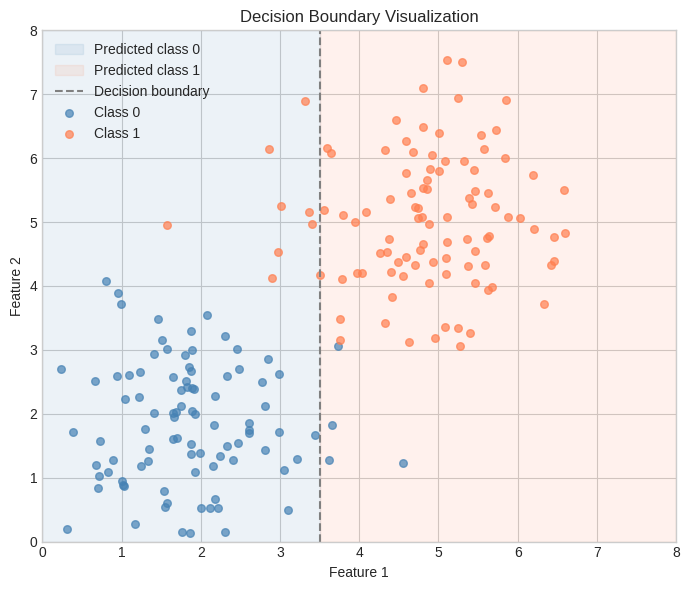

In [54]:
# Solution
rng = np.random.default_rng(10)
n = 100
X0 = rng.normal([2, 2], 1.0, (n, 2))
X1 = rng.normal([5, 5], 1.0, (n, 2))

fig, ax = plt.subplots(figsize=(7, 6))

# Shade decision regions (threshold at x=3.5)
ax.axvspan(0, 3.5, color='steelblue', alpha=0.1, label='Predicted class 0')
ax.axvspan(3.5, 8, color='coral',     alpha=0.1, label='Predicted class 1')
ax.axvline(x=3.5, color='gray', linewidth=1.5, linestyle='--', label='Decision boundary')

ax.scatter(X0[:, 0], X0[:, 1], color='steelblue', alpha=0.7, s=30, label='Class 0')
ax.scatter(X1[:, 0], X1[:, 1], color='coral',     alpha=0.7, s=30, label='Class 1')

ax.set_xlim(0, 8)
ax.set_ylim(0, 8)
ax.set_title("Decision Boundary Visualization")
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()


---

## 👨‍💻 Author

**Himanshu Kumar**

- 🌐 GitHub: [@himanshu231204](https://github.com/himanshu231204)
- 💼 LinkedIn: [himanshu231204](https://www.linkedin.com/in/himanshu231204)
- 🐦 Twitter/X: [@himanshu231204](https://twitter.com/himanshu231204)
- 📧 Email: himanshu231204@gmail.com
